In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')

df = pd.read_csv('flight_data_2024(act).csv', sep=';')

# Columna auxiliar de ruta
df['ruta'] = df['origin'] + ' → ' + df['dest']

Grafico 1) Top 10 rutas mas frecuentes 

Las rutas más transitadas conectan principalmente aeropuertos de Hawaii (OGG->HNL, HNL->OGG, KOA->HNL), lo que refleja la alta demanda de vuelos entre islas. Le siguen corredores costeros de alta densidad como JFK->LAX y LAX->JFK, rutas troncales que conectan las dos ciudades más importantes del país. La simetría entre rutas de ida y vuelta (OGG->HNL / HNL->OGG) confirma un flujo equilibrado de pasajeros en ambas direcciones.

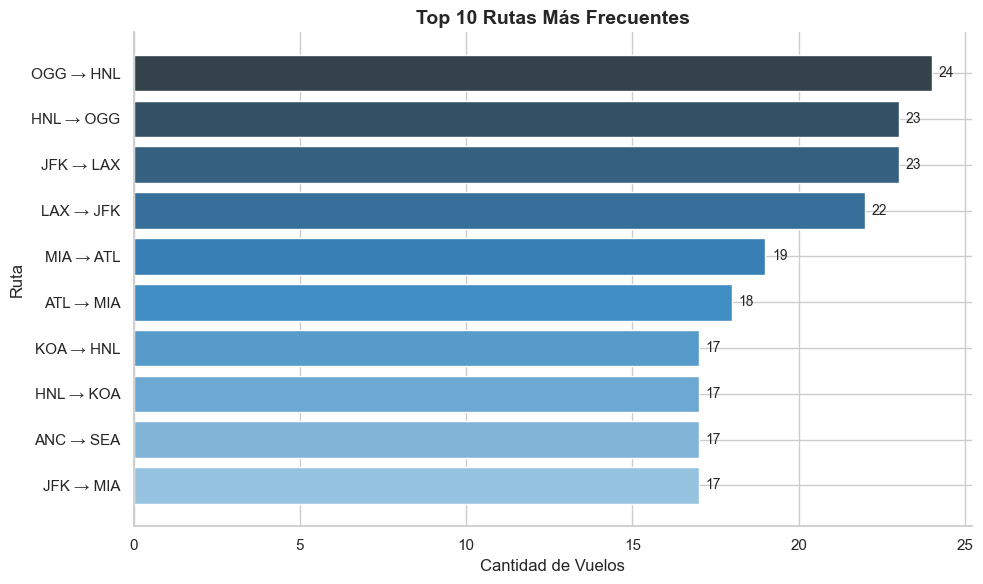

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

top_rutas = df['ruta'].value_counts().head(10).sort_values()

bars = ax.barh(top_rutas.index, top_rutas.values,
               color=sns.color_palette('Blues_d', 10))

for bar, val in zip(bars, top_rutas.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10)

ax.set_title('Top 10 Rutas Más Frecuentes', fontsize=14, fontweight='bold')
ax.set_xlabel('Cantidad de Vuelos')
ax.set_ylabel('Ruta')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Grafico 2) Top 10 ciudades de destino

Dallas/Fort Worth lidera con 607 vuelos, seguido de Atlanta con 551 y New York con 410. Estos tres aeropuertos son los principales hubs del sistema aéreo estadounidense, lo que explica su alta frecuencia como destinos. La presencia de ciudades como Charlotte, Seattle y Miami refuerza la idea de una red concentrada en grandes centros de conexión más que en destinos turísticos puntuales.

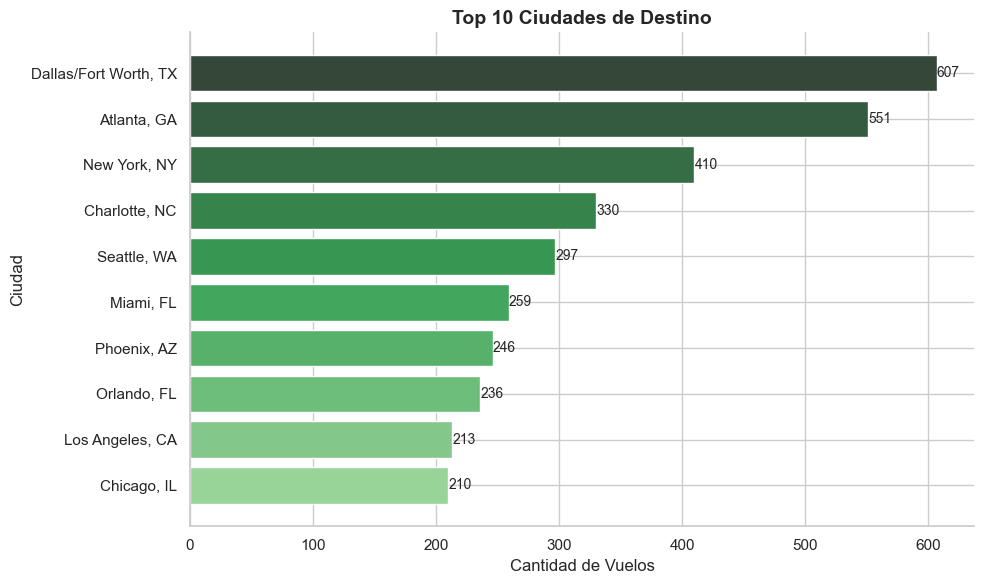

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

top_dest = df['dest_city_name'].value_counts().head(10).sort_values()

bars2 = ax.barh(top_dest.index, top_dest.values,
                color=sns.color_palette('Greens_d', 10))

for bar, val in zip(bars2, top_dest.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10)

ax.set_title('Top 10 Ciudades de Destino', fontsize=14, fontweight='bold')
ax.set_xlabel('Cantidad de Vuelos')
ax.set_ylabel('Ciudad')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Gráfico 3 – Distribución de Vuelos por Aerolínea

American Airlines (AA) domina con 2495 vuelos, seguida de Delta (DL) con 2027. Entre ambas concentran más del 60% del total de vuelos del dataset. Las aerolíneas de bajo costo como Frontier (F9) y Allegiant (G4) tienen participaciones menores, operando rutas más específicas. Esta concentración es característica del mercado aéreo estadounidense, donde pocas aerolíneas grandes dominan las rutas principales.

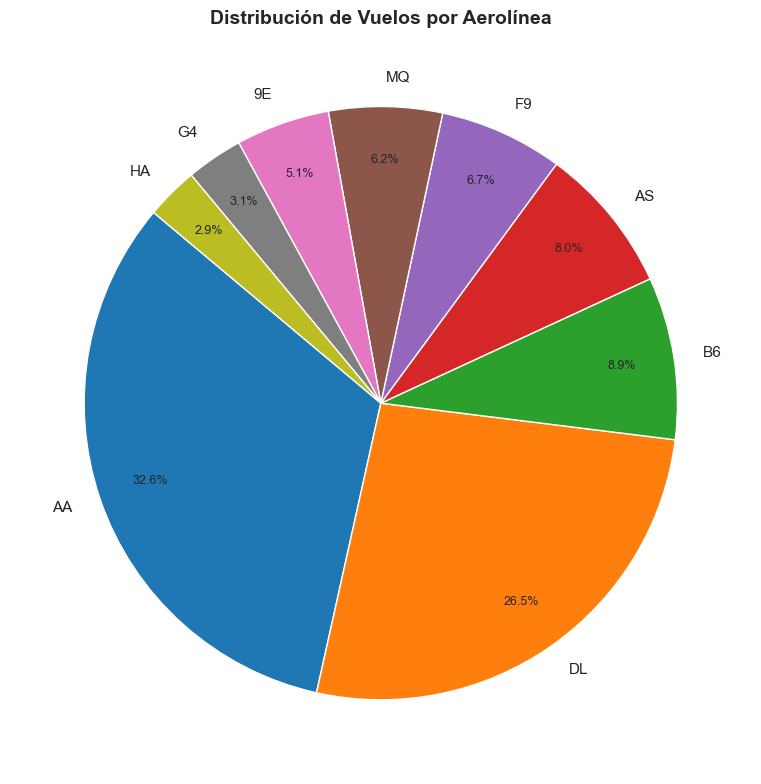

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))

carrier_counts = df['op_unique_carrier'].value_counts()

wedges, texts, autotexts = ax.pie(
    carrier_counts.values,
    labels=carrier_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('tab10', len(carrier_counts)),
    startangle=140,
    pctdistance=0.82
)

for t in autotexts:
    t.set_fontsize(9)

ax.set_title('Distribución de Vuelos por Aerolínea', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Gráfico 4 – Distancia por Estado de Origen (Boxplot)

Los territorios del Pacífico lideran con un promedio de 2599 millas, lo cual tiene sentido geográfico dado su aislamiento. California (1528) y Washington (1405) también muestran distancias altas por su posición en la costa oeste, desde donde los vuelos al este del país son naturalmente largos. Alaska (1364) refleja su conectividad con el continente. Los estados del este como New Jersey (1241) muestran distancias menores, típico de una red regional más densa y corta.

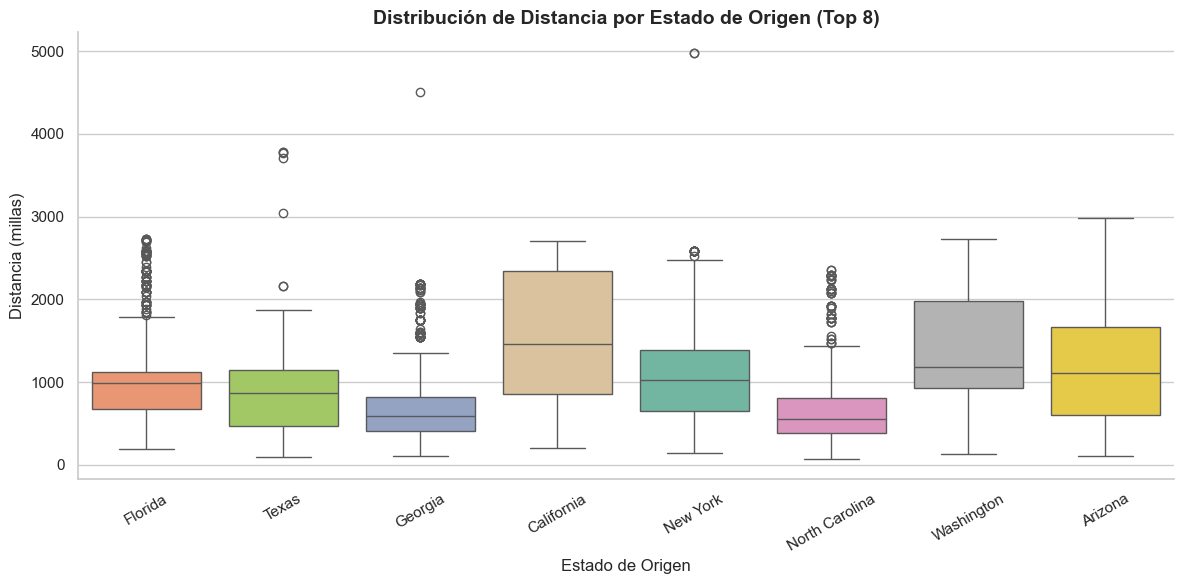

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

top_states = df['origin_state_nm'].value_counts().head(8).index
df_states = df[df['origin_state_nm'].isin(top_states)]

sns.boxplot(
    data=df_states,
    x='origin_state_nm',
    y='distance',
    hue='origin_state_nm',
    palette='Set2',
    legend=False,
    order=top_states,
    ax=ax
)

ax.set_title('Distribución de Distancia por Estado de Origen (Top 8)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Estado de Origen')
ax.set_ylabel('Distancia (millas)')
ax.tick_params(axis='x', rotation=30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()